In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import importlib
import meaplotter
importlib.reload(meaplotter)

from activity_qc_plotter import test_genotype_lmm

# ── Config ────────────────────────────────────────────────────────────────
CSV_PATH      = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig2/ActivityScan_outputs/Compiled_Activity_Summary.csv'
DIRPATH       = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig2/ActivityScan_outputs/'
GROUP_ORDER   = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE       = {'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}
SELECTED_DIVS = [8,16,23]   # mature timepoints only — limits FDR test family

METRICS = [
    ('Mean_FiringRate',   'Mean Firing Rate (Hz)'),
    ('Mean_SpikeAmplitude', 'Mean Spike Amplitude (uV)'),
    ('Active_area',       'Active Area (%)'),
    ('Mean_ISI',          'Mean ISI (s)'),
    ('Mean_ISI_CV',       'ISI CV'),
    ('Mean_Fano',         'Fano Factor'),
]

# ── Load + clean ──────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['DIV']        = df['DIV'].astype(int)
df['NeuronType'] = df['NeuronType'].str.strip()
df['Chip_ID']    = df['Chip_ID'].astype(str)
df['Well']       = df['Well'].astype(str)
df['CHIP_WELL']  = df['Chip_ID'] + '_' + df['Well']

# ── Exclude known bad wells ───────────────────────────────────────────────
EXCLUDE = {'M07039': '5'}   # Chip_ID -> Well  (from QC)
mask = df.apply(lambda r: EXCLUDE.get(r['Chip_ID']) == r['Well'], axis=1)
df = df[~mask].copy()

print(f'Loaded {len(df)} rows | {df["CHIP_WELL"].nunique()} wells | '
      f'DIV {df["DIV"].min()}-{df["DIV"].max()}')
print('Groups:', df['NeuronType'].value_counts().to_dict())


Loaded 144 rows | 18 wells | DIV 5-30
Groups: {'MxWT': 64, 'FxHET': 48, 'MxHEMI': 32}



######################################################################
# Mean Firing Rate (Hz)
######################################################################
LMM: Mean_FiringRate ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             3.239    2     0.1980     ns
  Genotype × DIV (trajectory)        6.097    2     0.0474      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0474).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                        0.799 

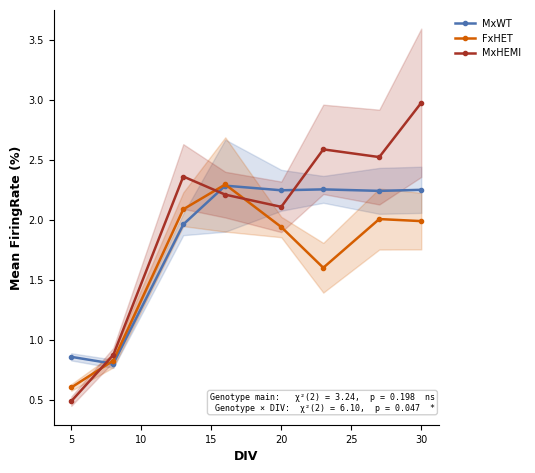


######################################################################
# Mean Spike Amplitude (uV)
######################################################################
LMM: Mean_SpikeAmplitude ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             5.612    2     0.0604     ns
  Genotype × DIV (trajectory)       37.163    2     0.0000    ***

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0000).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                     

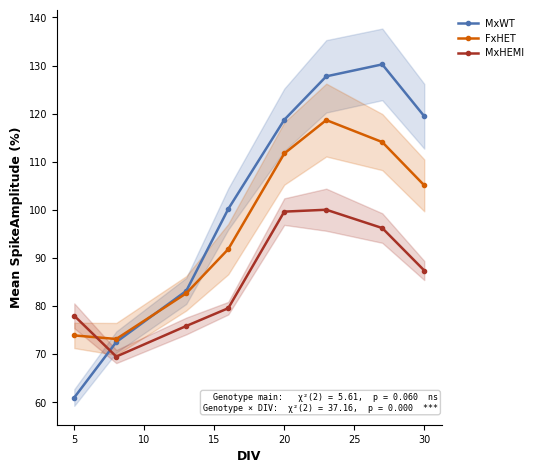


######################################################################
# Active Area (%)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


LMM: Active_area ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.088    2     0.9570     ns
  Genotype × DIV (trajectory)        1.796    2     0.4074     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                       31.103    4.519   6.883  0.000  22.246  39.960
C(NeuronType, Treatment('MxWT'))[T.FxHET]        5.734    6.903   0.831  0.406  -7.795  19.264
C(NeuronType, Treatment('MxWT'))[T.MxHEMI]       7.662    7.827   0.979  0.328  -7.679  23.003
DIV                                       

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.132377
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-

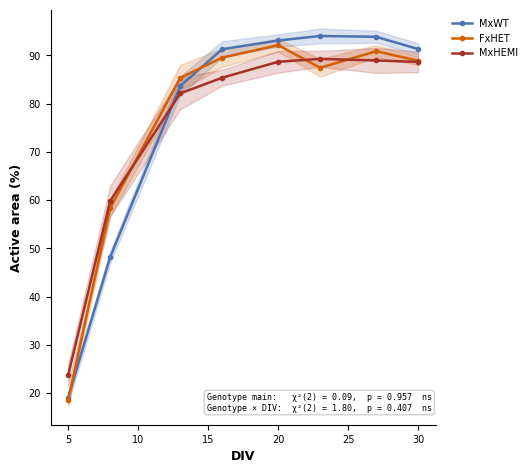


######################################################################
# Mean ISI (s)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


LMM: Mean_ISI ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.642    2     0.7256     ns
  Genotype × DIV (trajectory)        9.050    2     0.0108      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0108).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                                        9.118    0.465   19.602  0.000   8.207  10.030
C(NeuronType, Treatment('MxWT'))[T.FxHET]       -2.167    0.711   -3.050  0.002  -3.560  -0.774
C(NeuronType, Treatment('MxWT'))[T.

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


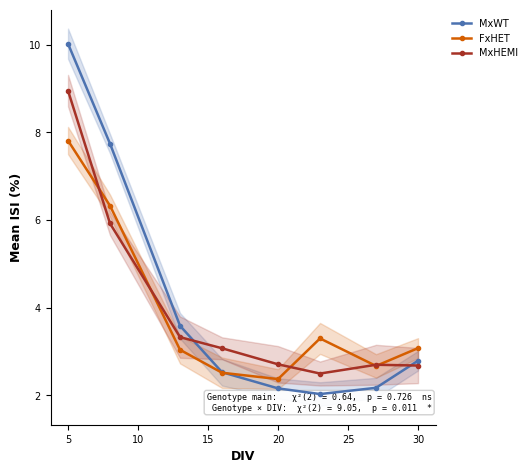


######################################################################
# ISI CV
######################################################################
LMM: Mean_ISI_CV ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             3.418    2     0.1811     ns
  Genotype × DIV (trajectory)        4.413    2     0.1101     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                        1.541    0.123  12.512  0.000   1.299   1.782
C(NeuronType, Treatment('MxWT'))[T.FxHET]        0.479    0.188   2.549  0.011  

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


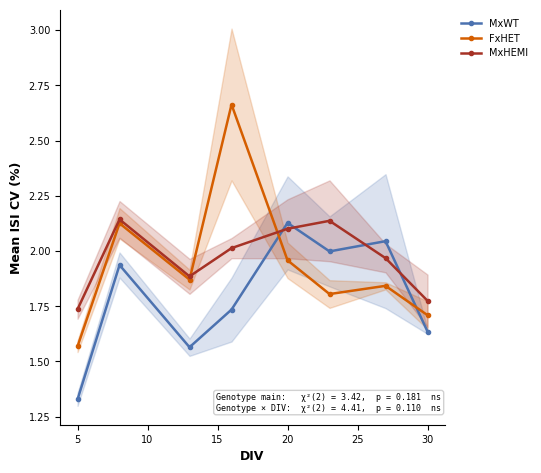


######################################################################
# Fano Factor
######################################################################
LMM: Mean_Fano ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             5.420    2     0.0665     ns
  Genotype × DIV (trajectory)        2.744    2     0.2537     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                        3.262    0.486   6.709  0.000   2.309  4.214
C(NeuronType, Treatment('MxWT'))[T.FxHET]        1.851    0.743   2.493  0.013 

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


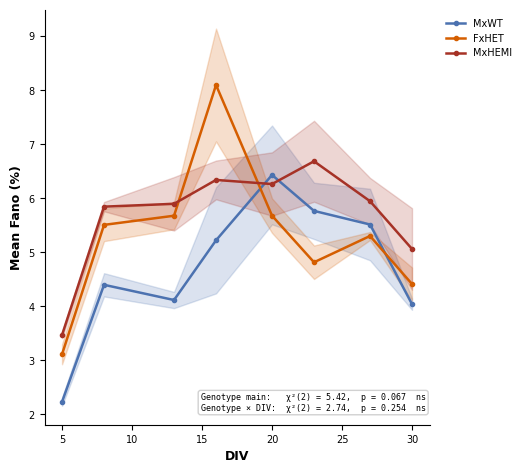


── LMM summary across metrics ──────────────────────────────────
             Metric  Main p Main sig  Interaction p Interaction sig
    Mean_FiringRate  0.1980       ns         0.0474               *
Mean_SpikeAmplitude  0.0604       ns         0.0000             ***
        Active_area  0.9570       ns         0.4074              ns
           Mean_ISI  0.7256       ns         0.0108               *
        Mean_ISI_CV  0.1811       ns         0.1101              ns
          Mean_Fano  0.0665       ns         0.2537              ns


In [2]:
# LMM: value ~ Genotype * DIV + (1 | CHIP_WELL)
# Two LRTs per metric: main genotype effect + genotype x DIV interaction.
# Run before trajectory plots to know which metrics show a genotype signal.

lmm_results = {}

for metric, ylabel in METRICS:
    if metric not in df.columns:
        continue
    print(f'\n{"#"*70}')
    print(f'# {ylabel}')
    print(f'{"#"*70}')
    fig, ax_data, ax_fit, lrt = test_genotype_lmm(
        df,
        group_col='NeuronType',
        div_col='DIV',
        value_col=metric,
        unit_col='CHIP_WELL',
        group_order=GROUP_ORDER,
        palette=PALETTE,
        figsize=(5.5, 5.0),
        save_path=os.path.join(DIRPATH, f'{metric}_lmm.svg'),
    )
    lmm_results[metric] = lrt
    plt.show()

# Summary table
rows = []
for metric, lrt in lmm_results.items():
    rows.append({
        'Metric':          metric,
        'Main p':          round(lrt['main']['p'], 4),
        'Main sig':        ('***' if lrt['main']['p']<0.001 else '**' if lrt['main']['p']<0.01
                            else '*' if lrt['main']['p']<0.05 else 'ns'),
        'Interaction p':   round(lrt['interaction']['p'], 4),
        'Interaction sig': ('***' if lrt['interaction']['p']<0.001 else '**' if lrt['interaction']['p']<0.01
                            else '*' if lrt['interaction']['p']<0.05 else 'ns'),
    })
print('\n── LMM summary across metrics ──────────────────────────────────')
print(pd.DataFrame(rows).to_string(index=False))


LMM: Mean_FiringRate ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             3.239    2     0.1980     ns
  Genotype × DIV (trajectory)        6.097    2     0.0474      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0474).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                        0.799    0.189   4.234  0.000   0.429  1.169
C(NeuronType, Treatment('MxWT'))[T.FxHET]        0.035    0.288   0.121  0.903  -0.530  0.600
C(NeuronType, Treatment('MxWT'))[T

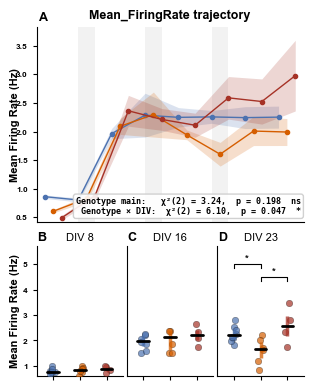

Mean_FiringRate — significant pairs (q < 0.05):
 DIV      comparison    q_val Sig
  23 FxHET vs MxHEMI 0.049509   *
  23   MxWT vs FxHET 0.049509   *

LMM: Mean_SpikeAmplitude ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             5.612    2     0.0604     ns
  Genotype × DIV (trajectory)       37.163    2     0.0000    ***

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0000).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                       51.717    4.628  1

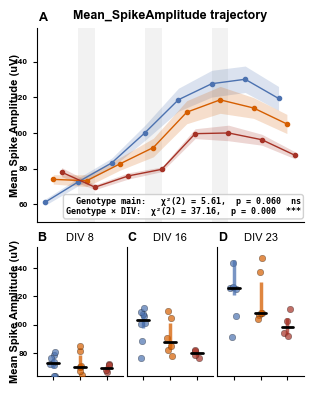

Mean_SpikeAmplitude — no significant pairs after FDR correction



/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/en

LMM: Active_area ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.088    2     0.9570     ns
  Genotype × DIV (trajectory)        1.796    2     0.4074     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                       31.103    4.519   6.883  0.000  22.246  39.960
C(NeuronType, Treatment('MxWT'))[T.FxHET]        5.734    6.903   0.831  0.406  -7.795  19.264
C(NeuronType, Treatment('MxWT'))[T.MxHEMI]       7.662    7.827   0.979  0.328  -7.679  23.003
DIV                                       

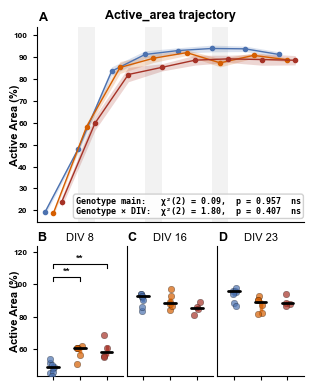

Active_area — significant pairs (q < 0.05):
 DIV     comparison    q_val Sig
   8  MxWT vs FxHET 0.009868  **
   8 MxWT vs MxHEMI 0.009868  **

LMM: Mean_ISI ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.642    2     0.7256     ns
  Genotype × DIV (trajectory)        9.050    2     0.0108      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0108).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept                                        9.118    0.465   19.602  0.000   8

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


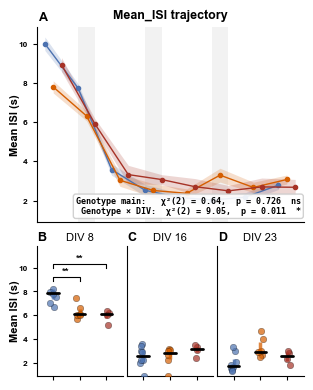

Mean_ISI — significant pairs (q < 0.05):
 DIV     comparison    q_val Sig
   8  MxWT vs FxHET 0.009868  **
   8 MxWT vs MxHEMI 0.009868  **

LMM: Mean_ISI_CV ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             3.418    2     0.1811     ns
  Genotype × DIV (trajectory)        4.413    2     0.1101     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                        1.541    0.123  12.512  0.000   1.299   1.782
C(NeuronType, Treatment('MxWT'))[T.FxHET]        0.479    0.188   2.549  0.011   0.111   0.

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


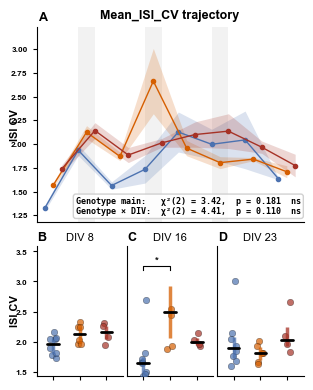

Mean_ISI_CV — significant pairs (q < 0.05):
 DIV    comparison   q_val Sig
  16 MxWT vs FxHET 0.02947   *

LMM: Mean_Fano ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 18

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             5.420    2     0.0665     ns
  Genotype × DIV (trajectory)        2.744    2     0.2537     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Fixed-effect coefficients (full model) ────────────────────
                                                 Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                        3.262    0.486   6.709  0.000   2.309  4.214
C(NeuronType, Treatment('MxWT'))[T.FxHET]        1.851    0.743   2.493  0.013   0.396  3.307
C(NeuronType, Treatment('MxWT'))[T.

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


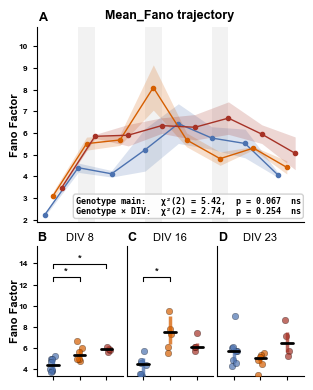

Mean_Fano — significant pairs (q < 0.05):
 DIV     comparison    q_val Sig
   8  MxWT vs FxHET 0.040274   *
   8 MxWT vs MxHEMI 0.039470   *
  16  MxWT vs FxHET 0.040274   *



In [3]:
# KW omnibus -> pairwise Wilcoxon -> BH-FDR across all (selected_div x pair)
# tests within each metric.  Stars shown only where q < 0.05.

viz = meaplotter.MEAPlotter(group_order=GROUP_ORDER, palette=PALETTE)
all_stats = {}
for metric, ylabel in METRICS:
    # fit LMM — stats only, no standalone figure
    _, _, _, lrt = test_genotype_lmm(
        df, value_col=metric, group_order=GROUP_ORDER, palette=PALETTE, plot=False,
    )

    # FDR stats at selected DIVs
    stats = viz.calculate_stats_at_timepoints(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
    )

    # ONE consolidated figure: trajectory + LMM badge + FDR dot panels
    fig, ax_traj, ax_dots = viz.plot_trajectory_with_dotplots(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, stats_df=stats,
        lmm_results=lrt,             # ← stamps the χ²/p badge on Panel A
        group_order=GROUP_ORDER, palette=PALETTE, ylabel=ylabel,
        figsize=(3.0, 4.2), height_ratios=(3, 2),
    )
    outpath = os.path.join(DIRPATH, f'{metric}_FDR.svg')
    fig.savefig(outpath, format='svg', bbox_inches='tight')
    plt.show()

    sig = stats[stats['reject'] == True][['DIV', 'comparison', 'q_val', 'Sig']]
    if not sig.empty:
        print(f'{metric} — significant pairs (q < 0.05):')
        print(sig.to_string(index=False))
    else:
        print(f'{metric} — no significant pairs after FDR correction')
    print()
